In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os

In [3]:
DATA_FOLDER = r"D:\cowork\Project Mortgage Deliquency\Project Data set"

COLS_TO_USE = [1, 2, 7, 9, 19, 20, 22, 23, 30, 34, 39, 43]

COL_NAMES = [
    "loan_id", "reporting_period", "orig_interest_rate", "orig_upb",
    "orig_ltv", "orig_cltv", "dti", "credit_score",
    "property_state", "amortization_type", "delinquency_status", "zero_balance_code"
]

print("✓ All imports loaded successfully")

✓ All imports loaded successfully


00 - current, paying on time loans
01 - 30 days late 
02 - 60 days late
03 - 90 days late
xx - unknown
76,77,...80 - shows the foreclouser proceding months - like for eg 80 is till 80 month (7 years) the property was not sold (ongoing)

200,000 rows represent the loan for one month 

In [5]:
csv_path = r"D:\cowork\Project Mortgage Deliquency\Project Data set\2021Q1.csv"

Final_db = []
for chunk in pd.read_csv(csv_path, sep = "|", header = None, dtype=str, usecols=COLS_TO_USE, chunksize = 300_000):

    chunk.columns = COL_NAMES

    chunk["delinquency_num"] = pd.to_numeric(
        chunk["delinquency_status"], errors="coerce"
    ).fillna(0).astype(int)
    #deliquency dta has numbers and str mixed, using pd.to_numeric to convert that in integers and turn NaN in 0 using the fillna(0), and defined the as type cause the pd.to_numeric by default save the number as float

    aggregate_db = chunk.groupby("loan_id").agg(
        orig_interest_rate=("orig_interest_rate", "first"),
        orig_upb=("orig_upb", "first"),
        orig_ltv=("orig_ltv", "first"),
        orig_cltv=("orig_cltv", "first"),
        dti=("dti", "first"),
        credit_score=("credit_score", "first"),
        property_state=("property_state", "first"),
        amortization_type=("amortization_type", "first"),
        worst_delinquency=("delinquency_num", "max")
    ).reset_index()

    Final_db.append(aggregate_db)

df_loans = pd.concat(Final_db, ignore_index=True)
df_loans = df_loans.groupby("loan_id").agg(
        orig_interest_rate=("orig_interest_rate", "first"),
        orig_upb=("orig_upb", "first"),
        orig_ltv=("orig_ltv", "first"),
        orig_cltv=("orig_cltv", "first"),
        dti=("dti", "first"),
        credit_score=("credit_score", "first"),
        property_state=("property_state", "first"),
        amortization_type=("amortization_type", "first"),
        worst_delinquency=("worst_delinquency", "max")
        ).reset_index()

print(f"Done, unique loans:{len(df_loans):}")
print(df_loans.head())


Done, unique loans:1413390
        loan_id orig_interest_rate  ... amortization_type worst_delinquency
0  000122128311              2.125  ...               FRM                 0
1  000122128312              2.625  ...               FRM                 0
2  000122128313              2.625  ...               FRM                 0
3  000122128314              2.750  ...               FRM                 0
4  000122128315              2.625  ...               FRM                 0

[5 rows x 10 columns]


In [6]:
print(df_loans.tail(10))

              loan_id orig_interest_rate  ... amortization_type worst_delinquency
1413380  000123541710              2.250  ...               FRM                 0
1413381  000123541711              2.375  ...               FRM                 0
1413382  000123541712              2.875  ...               FRM                 0
1413383  000123541713              2.500  ...               FRM                 0
1413384  000123541714              3.125  ...               FRM                 0
1413385  000123541715              2.750  ...               FRM                 0
1413386  000123541716              2.625  ...               FRM                 0
1413387  000123541717              3.125  ...               FRM                 0
1413388  000123541718              2.625  ...               FRM                 0
1413389  000123541719              2.750  ...               FRM                 0

[10 rows x 10 columns]


In [7]:
df_loans.to_csv(r"D:\cowork\Project Mortgage Deliquency\df_loans_2021Q1.csv", index=False)
print("Saved")

Saved


In [8]:
df_loans["defaulted"] = (df_loans["worst_delinquency"] >= 3).astype(int)

print(df_loans["defaulted"].value_counts())
print(f"Default rate: {df_loans['defaulted'].mean()*100:.2f}%")

defaulted
0    1391547
1      21843
Name: count, dtype: int64
Default rate: 1.55%


default rate for "prime mortgage" by the USA is in the range of 0.3-0.5 but in 2021 due to covid19 this shooted up, it could also be an atrifical spike

In [ ]:
model_variables = ["orig_interest_rate", "orig_ltv", "dti", "credit_score"]

for colums in model_variables: #take model variable and and loop through, temp store the current items in a variable colums
    df_loans[colums] = pd.to_numeric(df_loans[colums], errors="coerce") #converting the data type (model varibale data type) in numbers, error = "coerce" - is forcing empty values in NaN
#df_loans[colums] tells pandas which columns to look at in the df, colums becomes variable 1 (interest rate) in loop 1 then varibel 2 (ltv) in loop 2 and so on till loop 4 (variable 4)


print("Total Missing values per colums:")
print(df_loans[model_variables].isna().sum()) #how many missing isna in model variables therefore using isna().sum() 

df_clean = df_loans[model_variables+["defaulted"]].dropna() #df clean is new dataframe with 5 columns now - and droping the na

print(f"Rows before cleaning: {len(df_loans):,}")
print(f"Rows after cleaning:{len(df_clean):,}")
print(f"Rows dropped:{len(df_loans) - len(df_clean):,}")

Total Missing values per colums:
orig_interest_rate      0
orig_ltv                0
dti                    33
credit_score          386
dtype: int64
Rows before cleaning: 1,413,390
Rows after cleaning:1,412,971
Rows dropped:419


In banking, defaults are incredibly rare (highly imbalanced). If a random split accidentally dumps all defaults into the training set, the testing set becomes mathematically useless. Stratification fixes this by maintaining perfect class balance

In [ ]:
#Test and split 
from sklearn.model_selection import train_test_split

X = df_clean[model_variables]
Y = df_clean["defaulted"] #defining the dependent and independent variables

X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2,random_state=42, stratify=Y)

#train_test_split has a rule that- First output: The Training Features (inputs) Second output: The Testing Features (inputs)Third output: The Training Target (outputs/answers)Fourth output: The Testing Target (outputs/answers)

print(f"Training rows:  {len(X_train):,}")
print(f"Testing rows:   {len(X_test):,}")
print(f"Default rate in train: {Y_train.mean()*100:.2f}%")
print(f"Default rate in test:  {Y_test.mean()*100:.2f}%")

Training rows:  1,130,376
Testing rows:   282,595
Default rate in train: 1.55%
Default rate in test:  1.55%


Logistic Regression calculates coefficients (betas) based on a variable's raw numerical value. Credit scores exist in the hundreds (300–850), while debt-to-income and loan-to-value ratios exist as decimals or percentages (0.10–0.95). Without scaling, the model treats credit score variations as vastly more important simply because the numbers are orders of magnitude larger. Standardization translates all columns onto an identical, standard Z-score footprint.

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000)
model.fit(X_train_scaled,Y_train)

print("Model Trained Successfully")

Model Trained Successfully


scaler.fit_transform calculates the unique baseline average (mean) and spread (standard deviation) for each of your 4 variables on the training set, and then shifts those variables so they sit on a unified scale (mean of 0, standard deviation of 1).

Logistic Regression is a linear classification model that fits an S-curve (sigmoid function) to calculate the exact probability that an individual client sits in class 0 (Safe) or class 1 (Default). Because defaults are rare, a standard algorithm tries to maximize overall accuracy by guessing 0 for everyone. We apply a balanced class weight to artificially multiply the penalty whenever the model misses an actual defaulter, forcing the model to care equally about both outcomes

In [ ]:
weights = pd.Series(model.coef_[0], index=model_variables)
print("Model Weights (Risk Impact):\n", weights.sort_values(ascending=False)) #pulling up the optimized coefficients that the model.fit calculated for our independent variables and priniting them in decending order, while indexing with model variables

Model Weights (Risk Impact):
 orig_ltv              0.479730
dti                   0.360532
orig_interest_rate    0.114648
credit_score         -0.740188
dtype: float64


In [ ]:
from sklearn.metrics import (roc_auc_score, average_precision_score,accuracy_score,
                             confusion_matrix, classification_report)

Y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]
Y_pred = model.predict(X_test_scaled)
 
auc_roc = roc_auc_score(Y_test, Y_pred_prob) #area under the curve - receiver operating characterstic
auc_pr = average_precision_score(Y_test, Y_pred_prob)

print(f"AUC-ROC:              {auc_roc:.4f}")
print(f"Precision-Recall AUC: {auc_pr:.4f}")
print()
cm = confusion_matrix(Y_test, Y_pred)

print('Confusion matrix\n\n', cm)

print('\nTrue Negatives(TN)= ', cm[0,0])

print('\nTrue Positives(TP)  = ', cm[1,1])

print('\nFalse Negatives(FN) = ', cm[0,1])

print('\nFalse Positives(FP) = ', cm[1,0])
print()
print(classification_report(Y_test, Y_pred))


AUC-ROC:              0.7988
Precision-Recall AUC: 0.0670

Confusion matrix

 [[200631  77597]
 [  1119   3248]]

True Negatives(TN)=  200631

True Positives(TP)  =  3248

False Negatives(FN) =  77597

False Positives(FP) =  1119

              precision    recall  f1-score   support

           0       0.99      0.72      0.84    278228
           1       0.04      0.74      0.08      4367

    accuracy                           0.72    282595
   macro avg       0.52      0.73      0.46    282595
weighted avg       0.98      0.72      0.82    282595



Precision can be defined as the percentage of correctly predicted positive outcomes out of all the predicted positive outcomes. Precision = TP/(TP+FP)
Recall can be defined as the percentage of correctly predicted positive outcomes out of all the actual positive outcomes.Recall; = TP/(TP + FN) (also called sensitivity)
F1 score is the weighted mean of precision and recall.  The best possible f1-score would be 1.0 and the worst would be 0.0.
Support is the actual number of occurrences of the class in our dataset. 
Class 0 support = 278,228 — there are 278,228 loans that actually did NOT default in test set
Class 1 support = 4,367 — there are 4,367 loans that actually DID default in test set
Total = 282,595 — your full test set size

In [ ]:
for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    Y_pred_custom = (Y_pred_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(Y_test, Y_pred_custom).ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    print(f"Threshold {threshold:.1f} → Caught: {tp:,} defaults | False alarms: {fp:,} | Precision: {precision:.2f} | Recall: {recall:.2f}")

Threshold 0.3 → Caught: 3,953 defaults | False alarms: 147,805 | Precision: 0.03 | Recall: 0.91
Threshold 0.4 → Caught: 3,624 defaults | False alarms: 108,079 | Precision: 0.03 | Recall: 0.83
Threshold 0.5 → Caught: 3,248 defaults | False alarms: 77,597 | Precision: 0.04 | Recall: 0.74
Threshold 0.6 → Caught: 2,737 defaults | False alarms: 52,694 | Precision: 0.05 | Recall: 0.63
Threshold 0.7 → Caught: 2,090 defaults | False alarms: 31,335 | Precision: 0.06 | Recall: 0.48


AUC-ROC (Receiver Operating Characteristic)
This measures the overall balance between False Alarms (predicting Risk when it's actually Safe) and Caught Cases (correctly predicting Risk).

In plain terms: It answers the question, "If I randomly pick one actual Risk person and one actual Safe person, how confident is the model that the Risk person has a higher risk percentage?"

The Catch: AUC-ROC can be deceptively high if your dataset has a ton of 0s (Safe cases). If 95% of your data is Safe, the model can easily look great on this metric just by being good at identifying the Safe cases, even if it struggles with the rare Risk cases.

AUC_PR = area under the curve precision recall 
Precision: When the model flags someone as "Risk", how often is it actually right? (Or are there too many false alarms?)
Recall: Out of all the actual "Risk" cases hidden in the data, what percentage did the model successfully catch? 


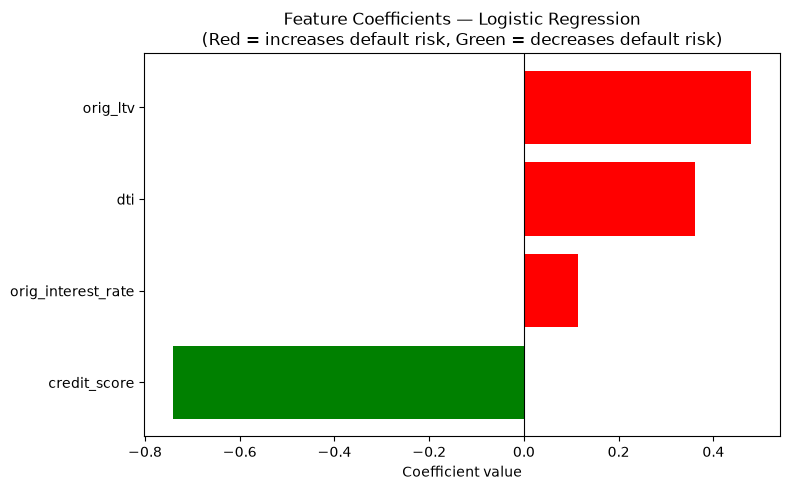

In [14]:
import matplotlib.pyplot as plt

coef_df = pd.DataFrame({
    "feature": model_variables,
    "coefficient": model.coef_[0]
}).sort_values("coefficient")

colors = ["red" if c > 0 else "green" for c in coef_df["coefficient"]]

plt.figure(figsize=(8, 5))
plt.barh(coef_df["feature"], coef_df["coefficient"], color=colors)
plt.axvline(x=0, color="black", linewidth=0.8)
plt.title("Feature Coefficients — Logistic Regression\n(Red = increases default risk, Green = decreases default risk)")
plt.xlabel("Coefficient value")
plt.tight_layout()
plt.show()

In [17]:
help(LogisticRegression)

Help on class LogisticRegression in module sklearn.linear_model._logistic:

class LogisticRegression(sklearn.callback._callback_support.CallbackSupportMixin, sklearn.linear_model._base.LinearClassifierMixin, sklearn.linear_model._base.SparseCoefMixin, sklearn.base.BaseEstimator)
 |  LogisticRegression(penalty='deprecated', *, C=1.0, l1_ratio=0.0, dual=False, tol=0.0001, fit_intercept=True, intercept_scaling=1, class_weight=None, random_state=None, solver='lbfgs', max_iter=100, verbose=0, warm_start=False, n_jobs=None)
 |
 |  Logistic Regression (aka logit, MaxEnt) classifier.
 |
 |  This class implements regularized logistic regression using a set of available
 |  solvers. **Note that regularization is applied by default**. It can handle both
 |  dense and sparse input `X`. Use C-ordered arrays or CSR matrices containing 64-bit
 |  floats for optimal performance; any other input format will be converted (and
 |  copied).
 |
 |  The solvers 'lbfgs', 'newton-cg', 'newton-cholesky' and 's